# Feature Distributions & Bin Strategy

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from feature_distributions import (
    add_relative_features,
    apply_class_groups,
    feature_percentiles,
    plot_per_class_distributions,
)
from histogram_separability import run_bin_sweep

## Build data

In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_class_groups(df)

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Percentiles

In [3]:
feature_percentiles(df)

                  n_points  rcs_p1  rcs_p50  rcs_p99  vr_compensated_p1  vr_compensated_p50  vr_compensated_p99  x_rel_p1  x_rel_p50  x_rel_p99  y_rel_p1  y_rel_p50  y_rel_p99  doppler_spread_p1  doppler_spread_p50  doppler_spread_p99
class                                                                                                                                                                                                                                     
car                 556288  -22.97    -1.35    23.42             -18.42                6.18               23.31     -2.11       0.00       2.25     -1.73       0.00       1.72                0.0                0.00               14.77
large_vehicle       202097  -18.72     3.24    29.97             -18.44                5.58               22.21     -7.01      -0.07       7.81     -3.67      -0.02       3.49                0.0                0.01               14.79
bus                  82494  -21.20    -1.67    25.40        

,n_points,rcs_p1,rcs_p50,rcs_p99,vr_compensated_p1,vr_compensated_p50,vr_compensated_p99,x_rel_p1,x_rel_p50,x_rel_p99,y_rel_p1,y_rel_p50,y_rel_p99,doppler_spread_p1,doppler_spread_p50,doppler_spread_p99
class,,,,,,,,,,,,,,,,
car,556288,-22.974434,-1.353382,23.421806,-18.424654,6.184389,23.314509,-2.105420,0.000000,2.247603,-1.734976,0.000000,1.721992,0.0,0.004425,14.771861
large_vehicle,202097,-18.717138,3.242924,29.965535,-18.442453,5.578499,22.208860,-7.014710,-0.073181,7.806723,-3.665558,-0.017445,3.492631,0.0,0.010012,14.792200
bus,82494,-21.199227,-1.666219,25.404242,-17.214939,5.797098,18.427563,-8.308375,-0.394030,10.409825,-5.783091,-0.030541,5.817387,0.0,0.014425,2.111149
two_wheeler,91088,-25.705622,-10.725831,6.901499,-5.830160,2.566195,10.343635,-0.768036,0.000000,0.860030,-0.671920,0.000000,0.662371,0.0,0.071699,0.961001
pedestrian,137044,-24.439101,-7.258938,7.016496,-2.498820,0.116695,2.775189,-0.404684,0.000000,0.469833,-0.414782,0.000000,0.392651,0.0,0.000000,0.920006
pedestrian_group,366304,-23.071605,-6.204597,7.062467,-2.195420,-0.203393,2.307327,-1.753605,0.000000,1.824931,-1.561212,0.000000,1.593638,0.0,0.108675,0.759126


## Per-class distributions

A distribution pooled across every class can look multimodal purely from mixing classes with
different central tendencies, not from any single class's own shape. This splits each feature
out per class to check.

Saved /home/bruno/radar_machine_learning_ws/results/feature_distributions/per_class_rcs.png


Saved /home/bruno/radar_machine_learning_ws/results/feature_distributions/per_class_vr_compensated.png


Saved /home/bruno/radar_machine_learning_ws/results/feature_distributions/per_class_x_rel.png


Saved /home/bruno/radar_machine_learning_ws/results/feature_distributions/per_class_y_rel.png


Saved /home/bruno/radar_machine_learning_ws/results/feature_distributions/per_class_doppler_spread.png


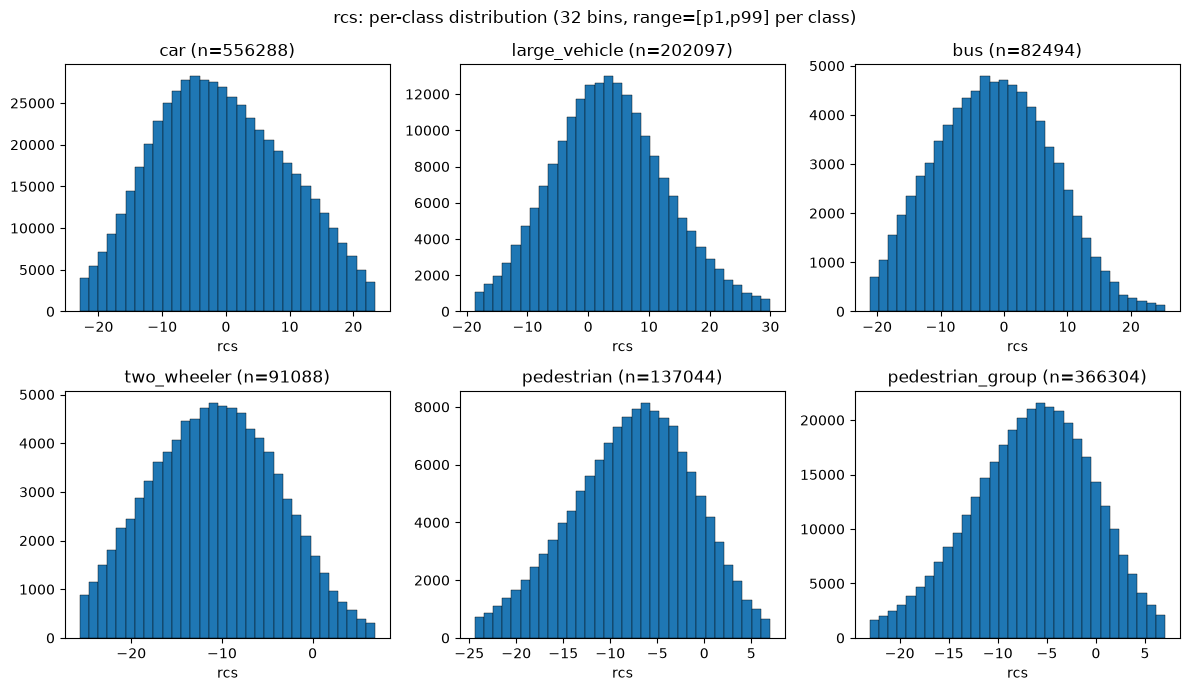

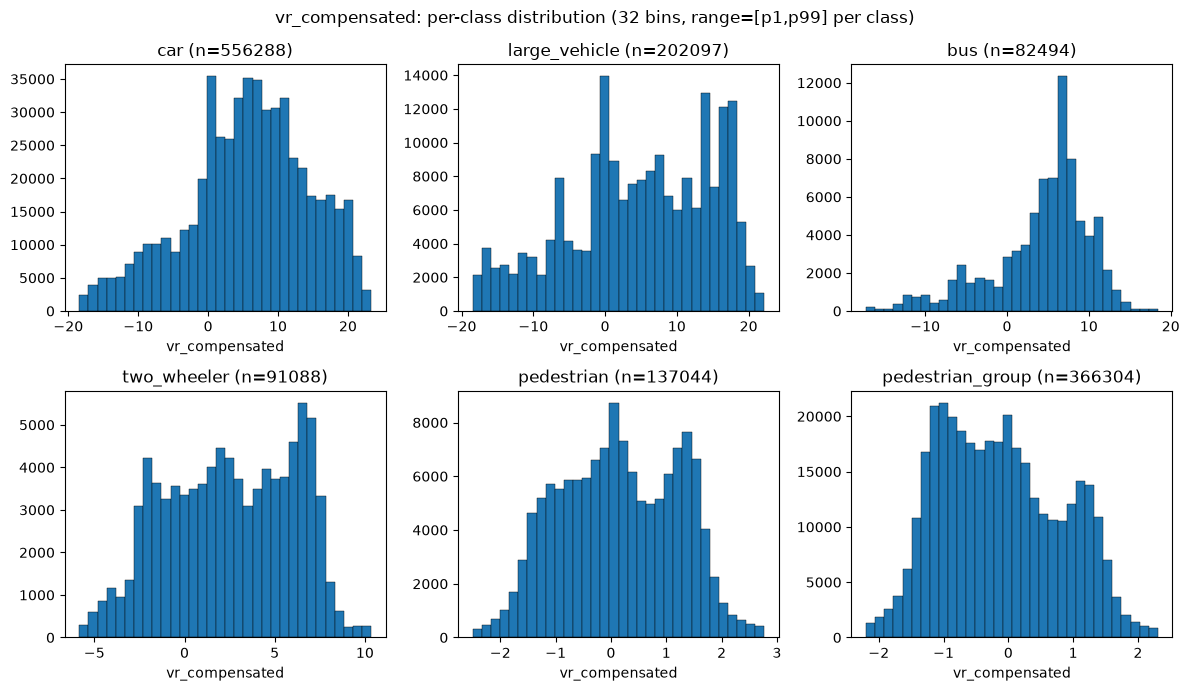

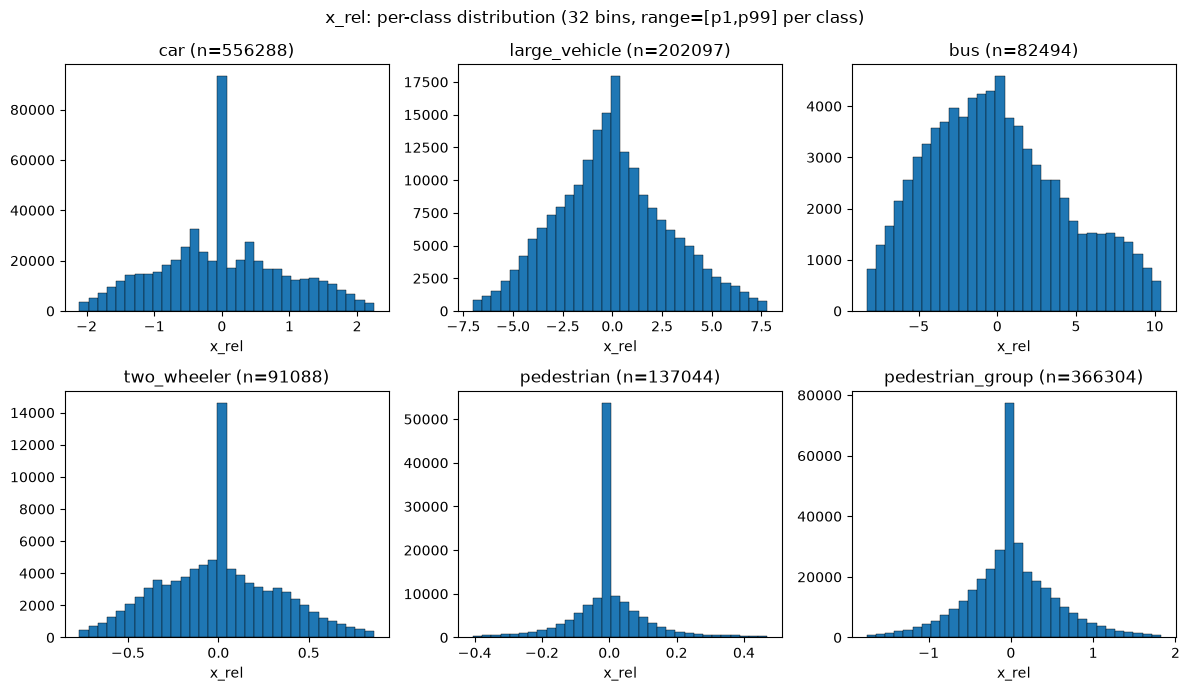

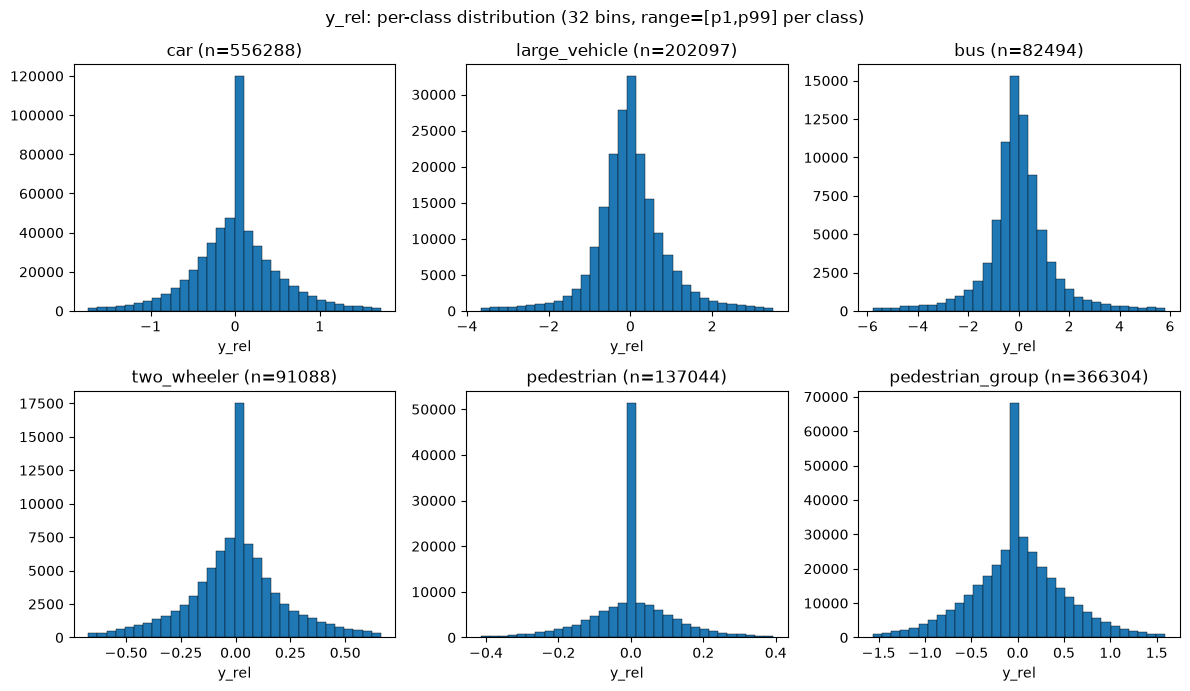

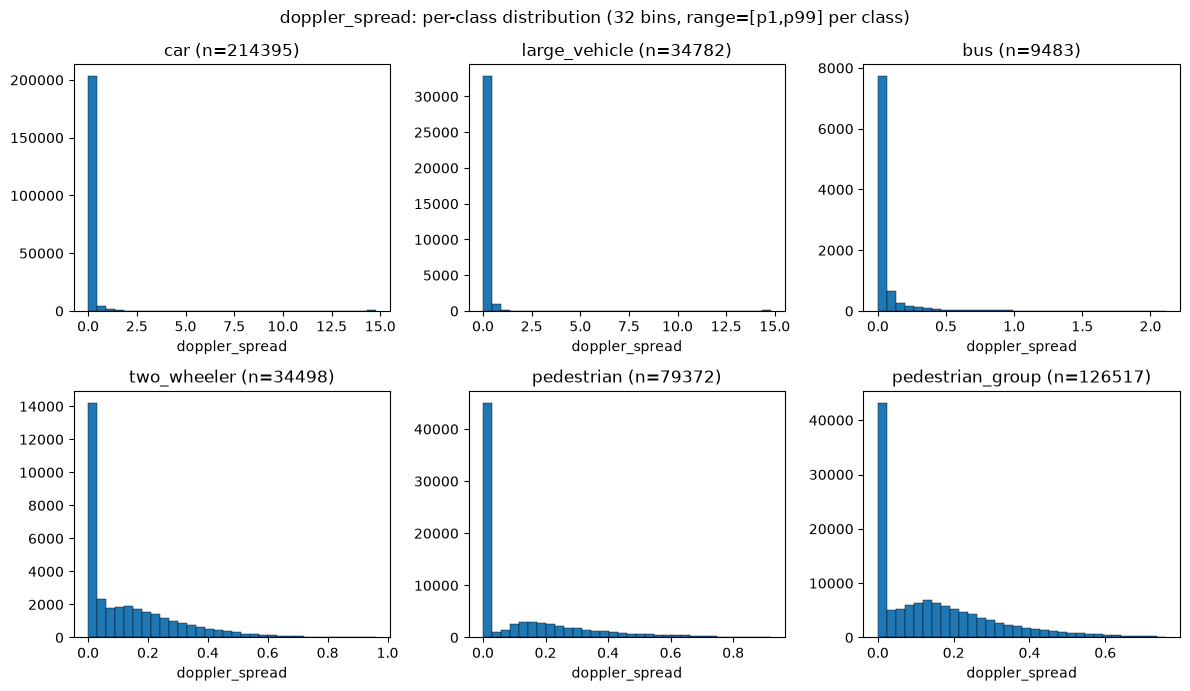

In [4]:
per_class_figs = plot_per_class_distributions(df)

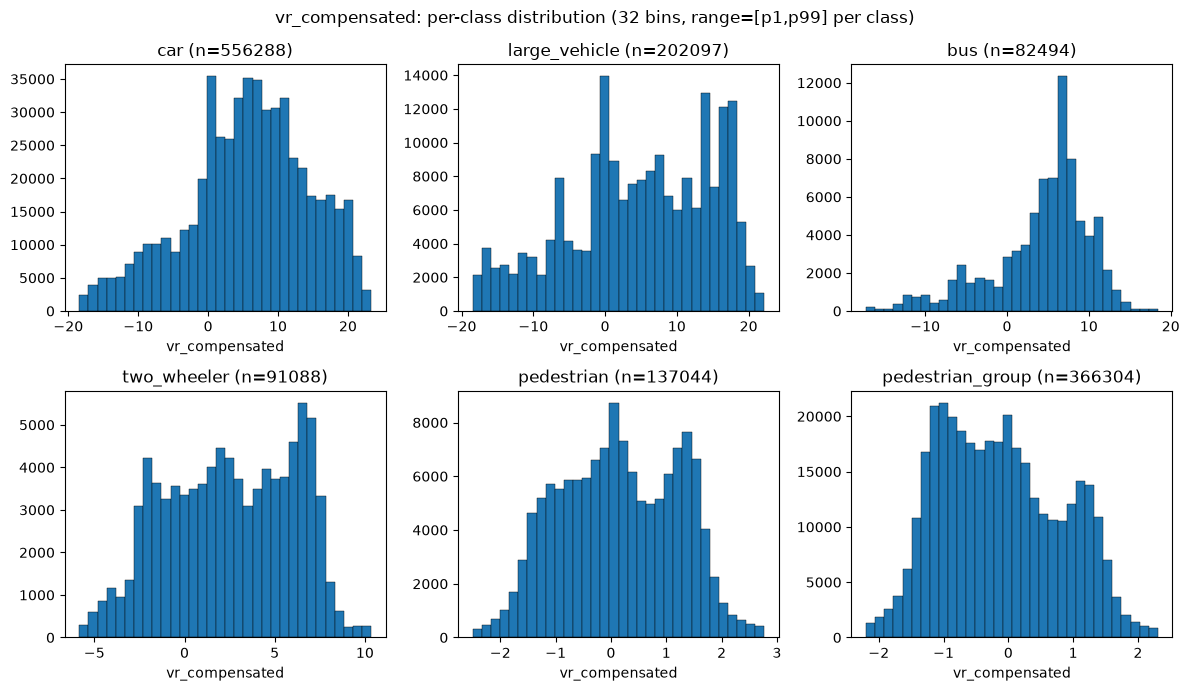

In [5]:
per_class_figs["vr_compensated"]

## Notes

The number of histogram bins can be treated as a hyperparameter of the encoding rather than being selected based on the visual characteristics of the resulting histograms. Its effect is better assessed through downstream classification performance, as the purpose of the encoding is to provide informative features for the classifier.

For the initial implementation, a provisional bin count is required. Given the observed average of approximately 2.87 radar points per instance, a relatively small number of bins, such as 4–8, was considered more appropriate than larger values such as 32 or 64. This value is not regarded as final and can be revised following empirical evaluation, using the existing taxonomy_separability.py probe with histogram-encoded features, the same approach used to decide whether to group some classes. Different bin counts can be compared using the same leakage-safe (i.e. per full sequence) cross-validation and AUC metric, allowing the final value to be selected based on classification performance.

## Bin count sweep via separability probe

Empirical alternative to visual inspection of the plots above: builds histogram-encoded per-instance
features at each candidate bin count and scores them with `separability_probe.run_probe_cv`'s
5-fold-averaged LR+RF probe, restricted to the fixed split's train+val sequences (test excluded -
see `Design_Decisions.md` decision 5), rather than judging resolution from the pooled plots or a
single held-out fold. See `histogram_separability.py`.

In [6]:
run_bin_sweep(df)

/home/bruno/radar_machine_learning_ws/results/histogram_separability/bin_sweep_results.parquet already covers bin_counts=(4, 8, 16, 32), skipping sweep
 n_bins               model  macro_auc_mean  auc_car_mean  auc_car_std  auc_large_vehicle_mean  auc_large_vehicle_std  auc_bus_mean  auc_bus_std  auc_two_wheeler_mean  auc_two_wheeler_std  auc_pedestrian_mean  auc_pedestrian_std  auc_pedestrian_group_mean  auc_pedestrian_group_std  macro_precision_mean  precision_car_mean  precision_car_std  precision_large_vehicle_mean  precision_large_vehicle_std  precision_bus_mean  precision_bus_std  precision_two_wheeler_mean  precision_two_wheeler_std  precision_pedestrian_mean  precision_pedestrian_std  precision_pedestrian_group_mean  precision_pedestrian_group_std  macro_recall_mean  recall_car_mean  recall_car_std  recall_large_vehicle_mean  recall_large_vehicle_std  recall_bus_mean  recall_bus_std  recall_two_wheeler_mean  recall_two_wheeler_std  recall_pedestrian_mean  recall_pedestrian_std 

,n_bins,model,macro_auc_mean,auc_car_mean,auc_car_std,auc_large_vehicle_mean,auc_large_vehicle_std,auc_bus_mean,auc_bus_std,auc_two_wheeler_mean,...,f1_large_vehicle_mean,f1_large_vehicle_std,f1_bus_mean,f1_bus_std,f1_two_wheeler_mean,f1_two_wheeler_std,f1_pedestrian_mean,f1_pedestrian_std,f1_pedestrian_group_mean,f1_pedestrian_group_std
0,4,logistic_regression,0.894226,0.926304,0.011367,0.869486,0.027645,0.939802,0.021256,0.860173,...,0.444925,0.080019,0.520506,0.072438,0.470714,0.126079,0.603710,0.036534,0.529518,0.059444
1,4,random_forest,0.873956,0.919677,0.009104,0.864300,0.039413,0.892874,0.042506,0.822949,...,0.532821,0.068536,0.506298,0.060158,0.471505,0.110176,0.572261,0.029114,0.554296,0.041490
2,8,logistic_regression,0.919823,0.949409,0.009195,0.884293,0.022404,0.945765,0.021482,0.912187,...,0.478457,0.065835,0.509983,0.060188,0.540614,0.101807,0.643292,0.035926,0.576207,0.063540
3,8,random_forest,0.910969,0.949545,0.007147,0.902636,0.025407,0.926675,0.038930,0.878708,...,0.589328,0.052769,0.493042,0.071667,0.533751,0.090835,0.619036,0.027442,0.617983,0.044357
4,16,logistic_regression,0.926439,0.951989,0.008726,0.886527,0.020754,0.947687,0.022613,0.922032,...,0.486131,0.066829,0.497028,0.059969,0.567782,0.098754,0.670360,0.034804,0.640284,0.057093
5,16,random_forest,0.925030,0.955909,0.007287,0.916038,0.025354,0.930818,0.029683,0.906053,...,0.611192,0.058871,0.504540,0.080219,0.583202,0.092113,0.650441,0.028131,0.659962,0.044993
6,32,logistic_regression,0.927752,0.954423,0.008285,0.886578,0.020971,0.940980,0.020971,0.929478,...,0.478391,0.049351,0.461441,0.065321,0.589537,0.085572,0.675260,0.032447,0.652043,0.051294
7,32,random_forest,0.928131,0.955522,0.007235,0.907853,0.029063,0.923987,0.033439,0.924932,...,0.611202,0.070431,0.454686,0.076799,0.615815,0.084124,0.660029,0.032047,0.690204,0.047853


**Decision:** 16 bins. Selected based on the random-forest separability probe rather than histogram visualization. Macro AUC improves substantially from 8 to 16 bins and then plateaus. Per-class F1 varies by class: large_vehicle performs best at 16 bins, while bus degrades with increasing resolution and two_wheeler continues improving to 32. Therefore, 16 bins provide the best overall compromise between discriminative performance, feature sparsity, and dimensionality.

**Confirmed with 5-fold CV on the fixed train+val split:**

| n_bins | model | macro AUC | macro F1 |
| --- | --- | --- | --- |
| 4 | RF | 0.874 | 0.577 |
| 8 | RF | 0.911 | 0.618 |
| 16 | RF | 0.925 | 0.647 |
| 32 | RF | 0.928 | 0.650 |

**Decision:** 16 bins. Five-fold cross-validation strengthens the choice: RF macro-F1 improves only marginally from 16 to 32 bins, while `large_vehicle` plateaus at 16. `bus` does not benefit from higher resolution, whereas two_wheeler continues to improve. Overall, 16 bins remain the best compromise between performance and feature dimensionality. See Design_Decisions.md, decision 3.